In [1]:
import re
import pdfplumber
from pathlib import Path
from rapidfuzz import fuzz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import unicodedata

In [ ]:
PDF_DIR    = Path("")        
OUTPUT_DIR = Path("")        
REPORT_DIR = Path("")        
FUZZY_THRESHOLD = 50

REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def extract_chapters_from_pdf(pdf_path: Path) -> dict[str, str]:
    full_text = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text:
                full_text.append(text)
    
    combined = "\n".join(full_text)
    lines    = combined.splitlines()
    
    def is_header(line: str) -> bool:
        line = line.strip()
        if not line or len(line) > 80:
            return False
        if line.endswith((".", ",", ";")):
            return False
        upper_ratio = sum(1 for c in line if c.isupper()) / max(len(line), 1)
        return upper_ratio > 0.5 or line.istitle()
    
    chapters = {}
    current_header = "__preamble__"
    current_lines  = []
    
    for line in lines:
        if is_header(line):
            if current_lines:
                chapters[current_header] = "\n".join(current_lines)
            current_header = line.strip()
            current_lines  = []
        else:
            current_lines.append(line)
    
    if current_lines:
        chapters[current_header] = "\n".join(current_lines)
    
    return chapters

def normalize_text(text: str) -> str:
    if not text:
        return ""
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", errors="ignore").decode("ascii")
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'["""]', '"', text)
    text = re.sub(r"[''']", "'", text)
    text = re.sub(r'[–—]', '-', text)
    text = re.sub(r'^[\(\[]?[Qq]?\d+[\)\]\.]\s*', '', text)
    return text.strip().lower()

def is_non_english(text: str) -> bool:
    if not text:
        return False
    non_ascii = sum(1 for c in text if ord(c) > 127)
    return (non_ascii / max(len(text), 1)) > 0.2

def question_in_text(question: str, text: str, threshold: int = FUZZY_THRESHOLD) -> tuple[bool, float]:
    q    = normalize_text(question)
    t    = normalize_text(text)
    if not q:
        return False, 0.0
    score = fuzz.partial_ratio(q, t)
    return score >= threshold, score


In [ ]:
all_results = []

subject_dirs = [d for d in OUTPUT_DIR.iterdir() if d.is_dir()]

for subj_dir in subject_dirs:
    subject = subj_dir.name
    class_dirs = [d for d in subj_dir.iterdir() if d.is_dir()]

    for class_dir in class_dirs:
        class_num = class_dir.name.replace("Class_", "").strip()    
        pdf_path = PDF_DIR / f"{subject}_{class_num}.pdf"
        if not pdf_path.exists():
            continue
        
        pdf_chapters = extract_chapters_from_pdf(pdf_path)
        full_pdf_text = "\n".join(pdf_chapters.values())
        
        csv_files = list(class_dir.glob("*.csv"))
        for csv_file in csv_files:
            df = pd.read_csv(csv_file)
            if "text" not in df.columns: continue

            chapter_name = csv_file.stem  
            matched_section = None
            best_section_score = 0
            for pdf_heading in pdf_chapters:
                score = fuzz.partial_ratio(chapter_name.lower(), pdf_heading.lower())
                if score > best_section_score:
                    best_section_score = score
                    matched_section = pdf_heading
            
            search_text = (
                pdf_chapters[matched_section]
                if matched_section and best_section_score >= 60
                else full_pdf_text
            )
            
            found_flags = []
            scores      = []
            for q in df["text"].fillna(""):
                matched, score = question_in_text(q, search_text)
                found_flags.append(matched)
                scores.append(score)
            
            df["found_in_pdf"]   = found_flags
            df["match_score"]    = scores
            df["pdf_source"]     = pdf_path.name
            df["pdf_section"]    = matched_section or "full_doc"
            
            df.to_csv(csv_file, index=False)
            all_results.append(df)
            n_found   = sum(found_flags)
            n_total   = len(found_flags)

In [ ]:
combined = pd.concat(all_results, ignore_index=True)

summary = (
    combined.groupby(["subject", "class", "chapter_title"])
    .agg(
        total_questions   = ("text", "count"),
        found_in_pdf      = ("found_in_pdf", "sum"),
        avg_match_score   = ("match_score", "mean"),
    )
    .reset_index()
)
summary["missing"]      = summary["total_questions"] - summary["found_in_pdf"]
summary["coverage_pct"] = (summary["found_in_pdf"] / summary["total_questions"] * 100).round(1)
summary.to_csv(REPORT_DIR / "coverage_summary.csv", index=False)

missing = combined[~combined["found_in_pdf"]].copy()
missing.to_csv(REPORT_DIR / "missing_questions.csv", index=False)

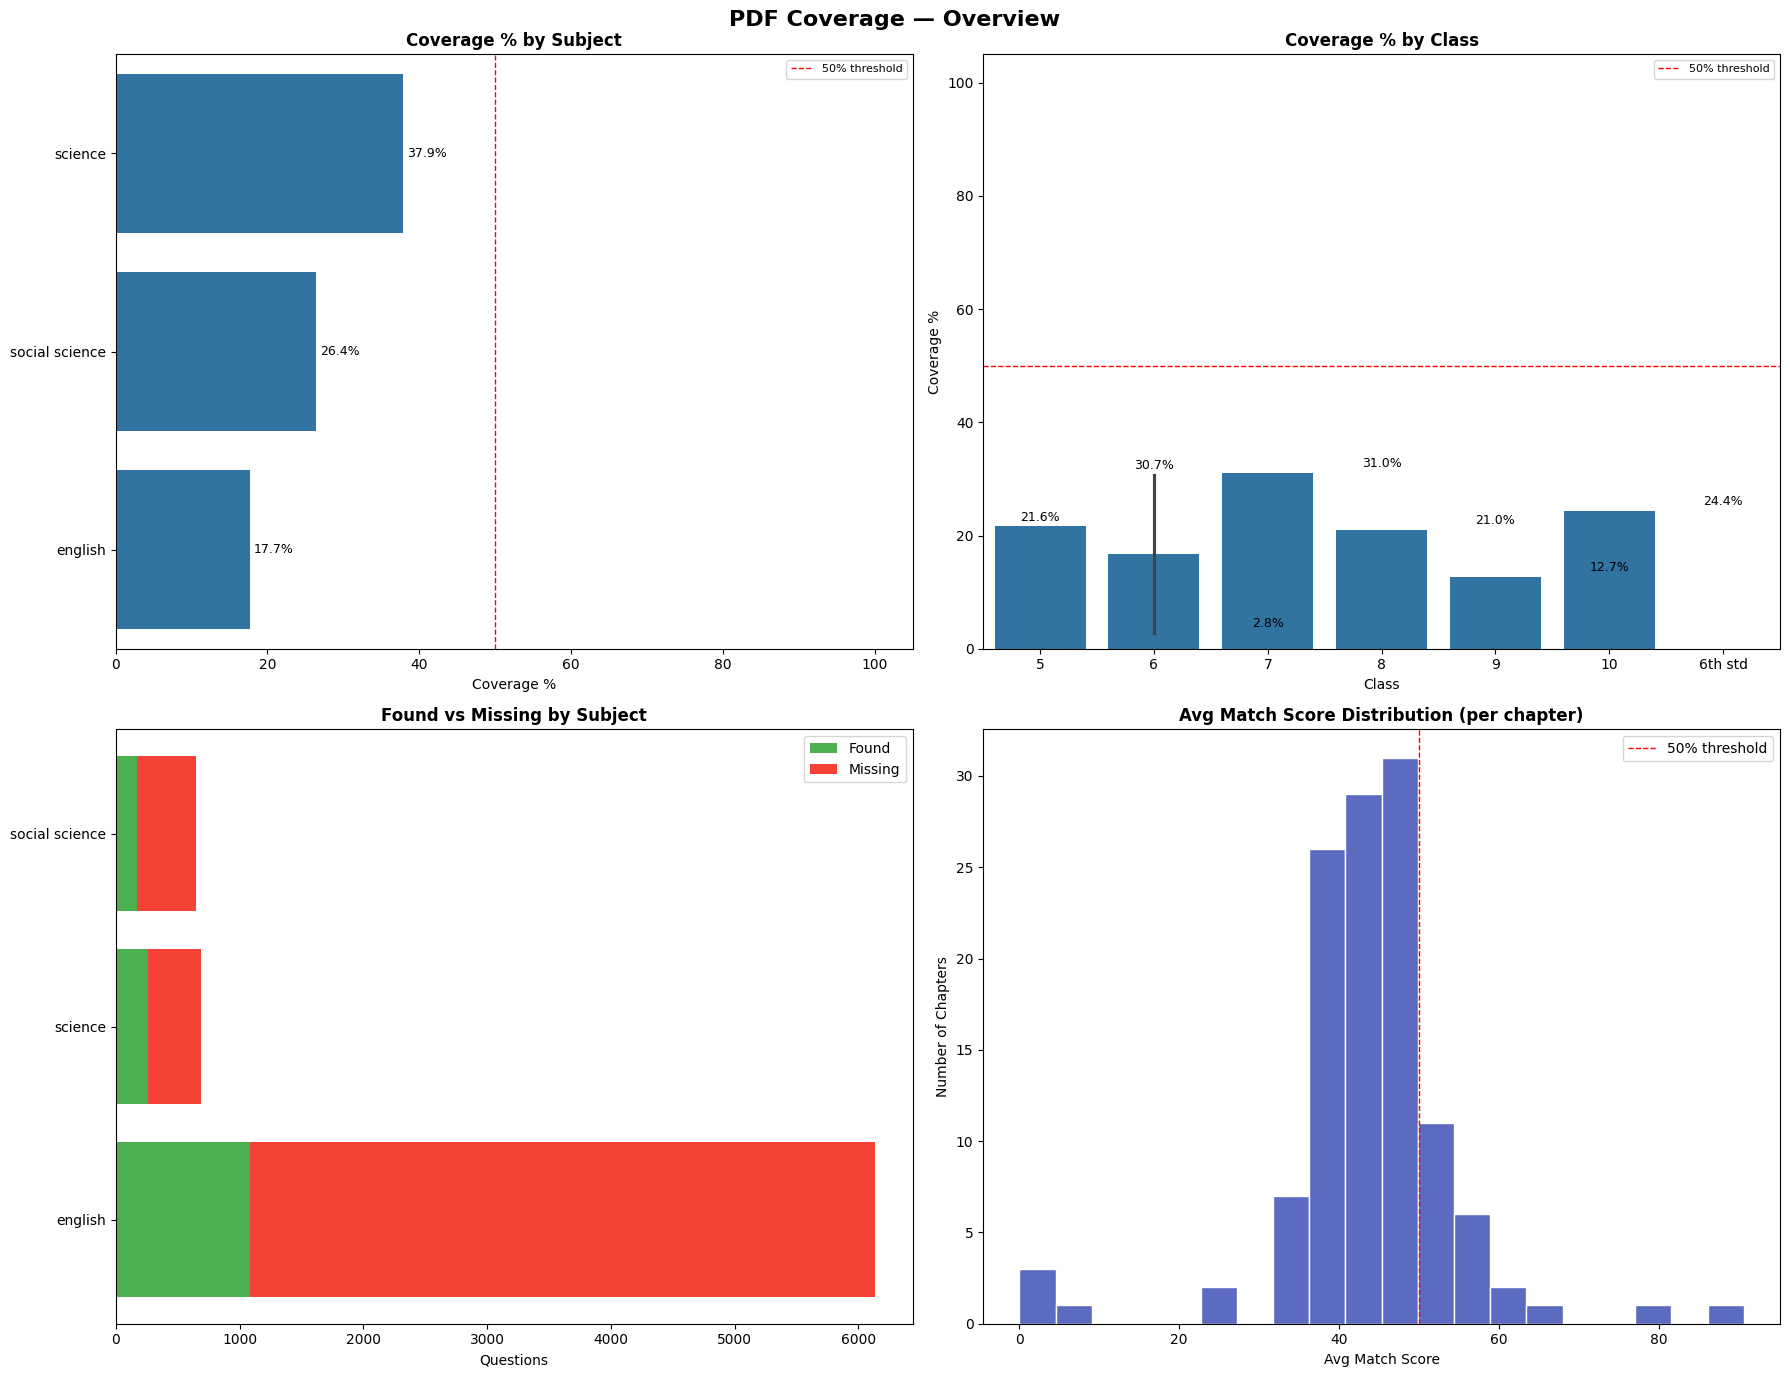

In [ ]:
fig1, axes = plt.subplots(2, 2, figsize=(18, 14))
fig1.suptitle("PDF Coverage — Overview", fontsize=16, fontweight="bold")

ax = axes[0, 0]
subj_cov = (
    summary.groupby("subject")
    .agg(found=("found_in_pdf", "sum"), total=("total_questions", "sum"))
    .assign(coverage_pct=lambda d: d["found"] / d["total"] * 100)
    .sort_values("coverage_pct", ascending=False)
    .reset_index()
)
bars = sns.barplot(data=subj_cov, x="coverage_pct", y="subject", ax=ax)
ax.axvline(50, color="red", linestyle="--", linewidth=1, label="50% threshold")
ax.set_title("Coverage % by Subject", fontweight="bold")
ax.set_xlabel("Coverage %")
ax.set_ylabel("")
ax.set_xlim(0, 105)
ax.legend(fontsize=8)
for i, row in subj_cov.iterrows():
    ax.text(row["coverage_pct"] + 0.5, i, f'{row["coverage_pct"]:.1f}%', va="center", fontsize=9)

ax = axes[0, 1]
summary["class_numeric"] = pd.to_numeric(summary["class"], errors='coerce')
class_cov = (
    summary.groupby("class")
    .agg(
        found=("found_in_pdf", "sum"), 
        total=("total_questions", "sum"),
        sort_key=("class", lambda x: pd.to_numeric(x, errors='coerce').iloc[0]) 
    )
    .assign(coverage_pct=lambda d: d["found"] / d["total"] * 100)
    .sort_values("sort_key")
    .reset_index()
)
sns.barplot(data=class_cov, x="class", y="coverage_pct", ax=ax)
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="50% threshold")
ax.set_title("Coverage % by Class", fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Coverage %")
ax.set_ylim(0, 105)
ax.legend(fontsize=8)
for i, row in class_cov.iterrows():
    ax.text(i, row["coverage_pct"] + 1, f'{row["coverage_pct"]:.1f}%', ha="center", fontsize=9)

ax = axes[1, 0]
subj_stack = (
    summary.groupby("subject")
    .agg(found=("found_in_pdf", "sum"), missing=("missing", "sum"))
    .reset_index()
    .sort_values("found", ascending=False)
)
ax.barh(subj_stack["subject"], subj_stack["found"],   color="#4CAF50", label="Found")
ax.barh(subj_stack["subject"], subj_stack["missing"], left=subj_stack["found"], color="#F44336", label="Missing")
ax.set_title("Found vs Missing by Subject", fontweight="bold")
ax.set_xlabel("Questions")
ax.set_ylabel("")
ax.legend()

ax = axes[1, 1]
all_scores = summary["avg_match_score"].dropna()
ax.hist(all_scores, bins=20, color="#5C6BC0", edgecolor="white")
ax.axvline(50, color="red", linestyle="--", linewidth=1, label="50% threshold")
ax.set_title("Avg Match Score Distribution (per chapter)", fontweight="bold")
ax.set_xlabel("Avg Match Score")
ax.set_ylabel("Number of Chapters")
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\adity\AppData\Local\Temp\ipykernel_26580\404439403.py:21: UserWarning: Glyph 3207 (\N{KANNADA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adity\AppData\Local\Temp\ipykernel_26580\404439403.py:21: UserWarning: Matplotlib currently does not support Kannada natively.
  plt.tight_layout()
C:\Users\adity\AppData\Local\Temp\ipykernel_26580\404439403.py:21: UserWarning: Glyph 3236 (\N{KANNADA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adity\AppData\Local\Temp\ipykernel_26580\404439403.py:21: UserWarning: Glyph 3263 (\N{KANNADA VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adity\AppData\Local\Temp\ipykernel_26580\404439403.py:21: UserWarning: Glyph 3257 (\N{KANNADA LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adity\AppData\Local\Temp\ipykernel_26580\404439403.py:21: UserWarning: Glyph 3262 (\N{KANNADA VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.ti

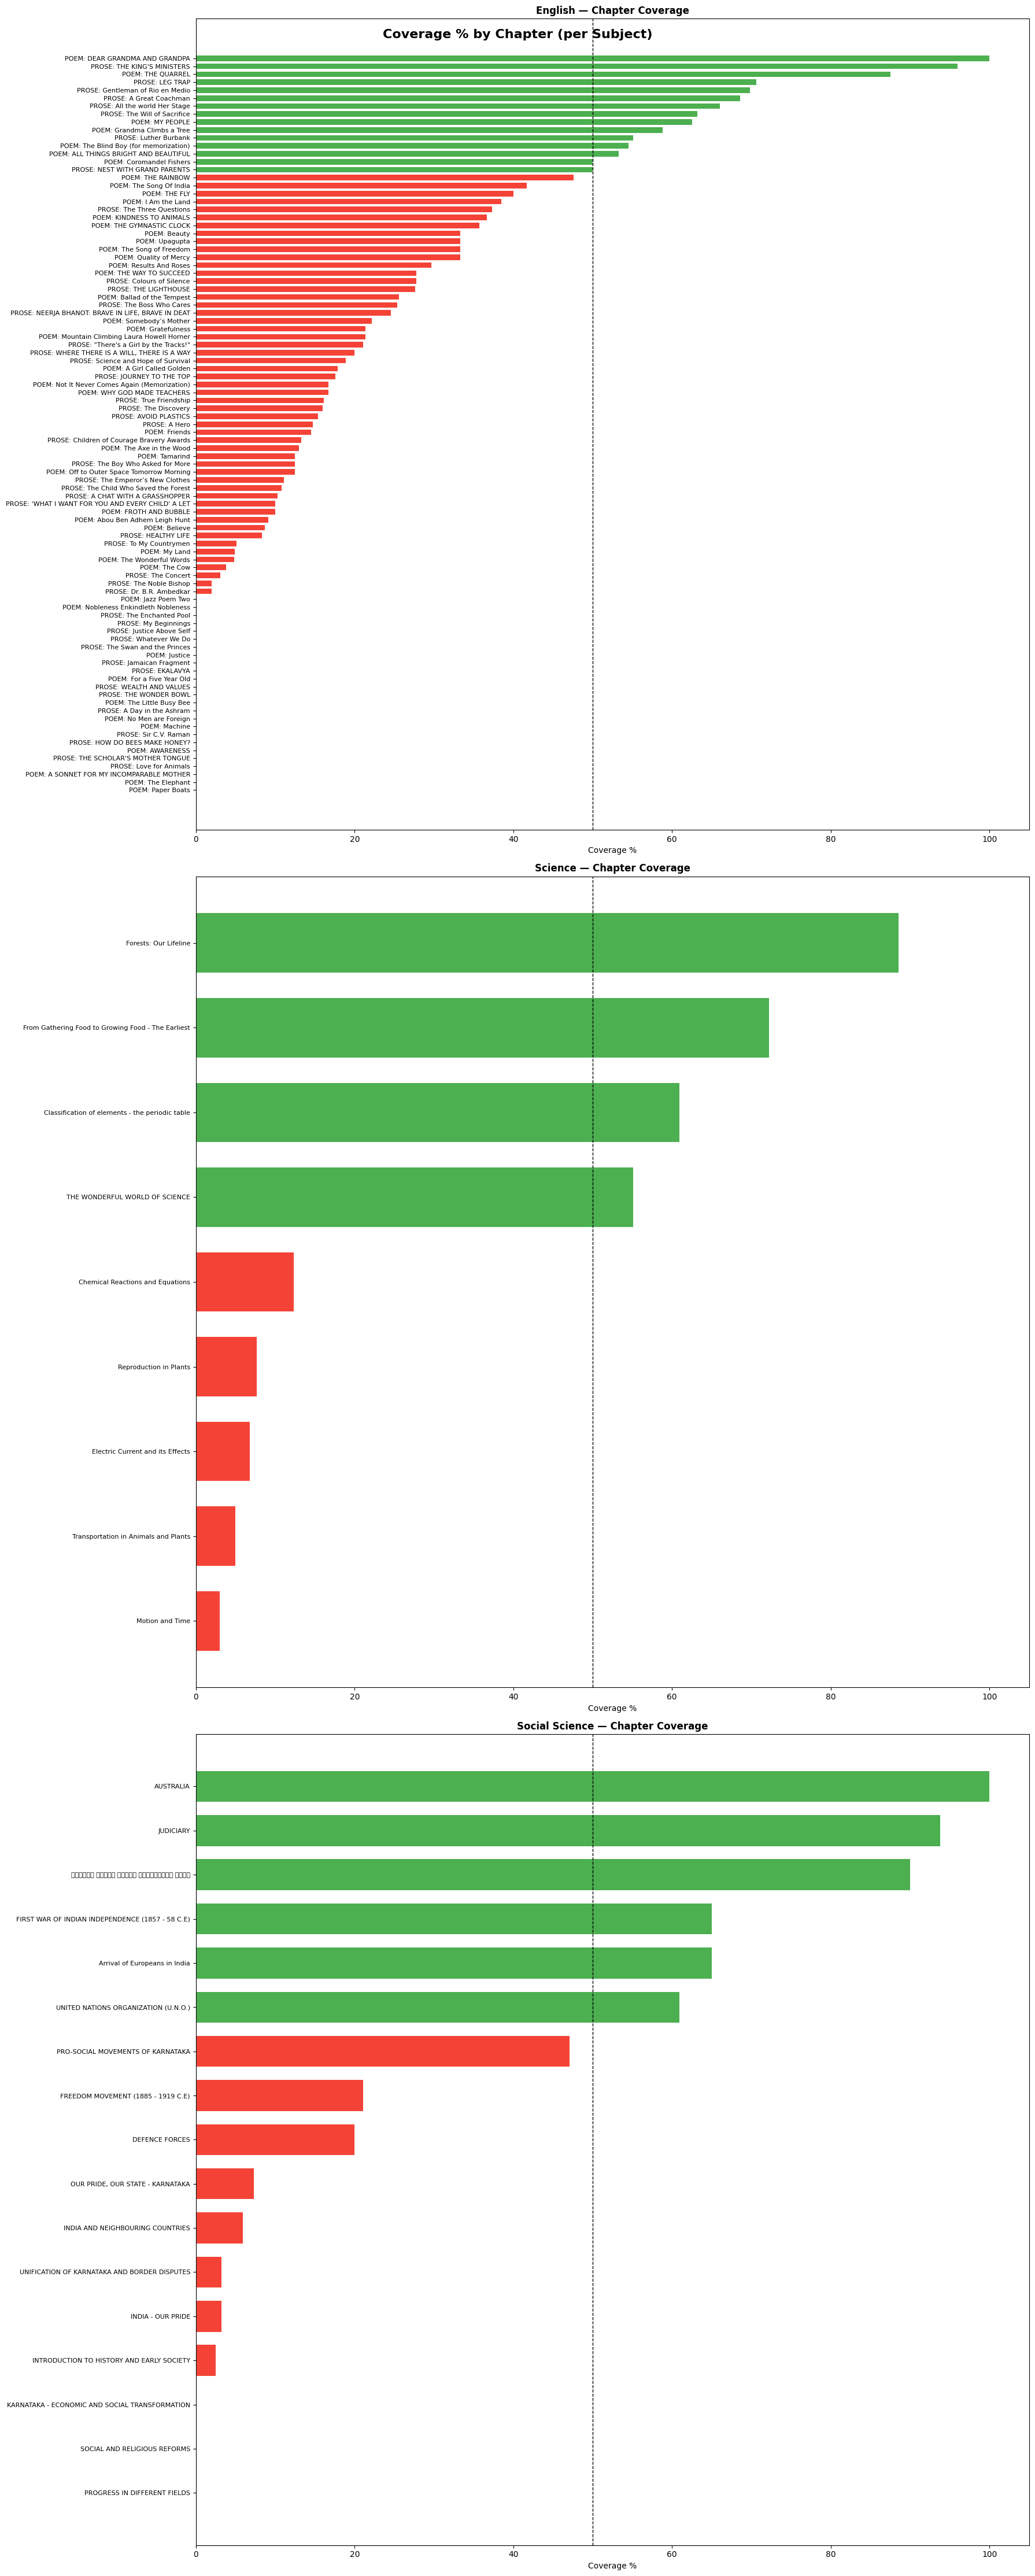

In [ ]:
subjects    = summary["subject"].unique()
n_subjects  = len(subjects)
fig2, axes2 = plt.subplots(n_subjects, 1, figsize=(18, 15 * n_subjects))
if n_subjects == 1:
    axes2 = [axes2]
fig2.suptitle("Coverage % by Chapter (per Subject)", fontsize=16, fontweight="bold")

for ax, subject in zip(axes2, subjects):
    sub = (
        summary[summary["subject"] == subject]
        .sort_values("coverage_pct", ascending=True)
    )
    colors = ["#F44336" if p < 50 else "#4CAF50" for p in sub["coverage_pct"]]
    ax.barh(sub["chapter_title"].str[:50], sub["coverage_pct"], color=colors, height=0.7)
    ax.axvline(50, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{subject.title()} — Chapter Coverage", fontweight="bold")
    ax.set_xlabel("Coverage %")
    ax.set_xlim(0, 105)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

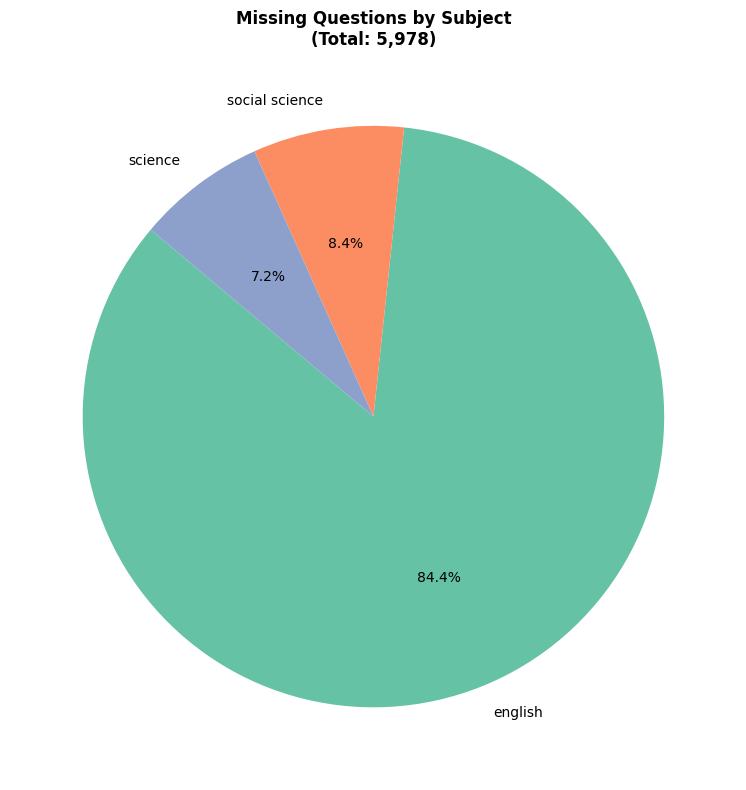

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.pie(
    missing_by_subj.values,
    labels=missing_by_subj.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Set2", len(missing_by_subj))
)

ax.set_title(f"Missing Questions by Subject\n(Total: {len(missing):,})", fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\adity\AppData\Local\Temp\ipykernel_26580\1229805260.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
c:\Users\adity\OneDrive\Documents\Sem 6\Shiksha_Copilot_Logs\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\adity\OneDrive\Documents\Sem 6\Shiksha_Copilot_Logs\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


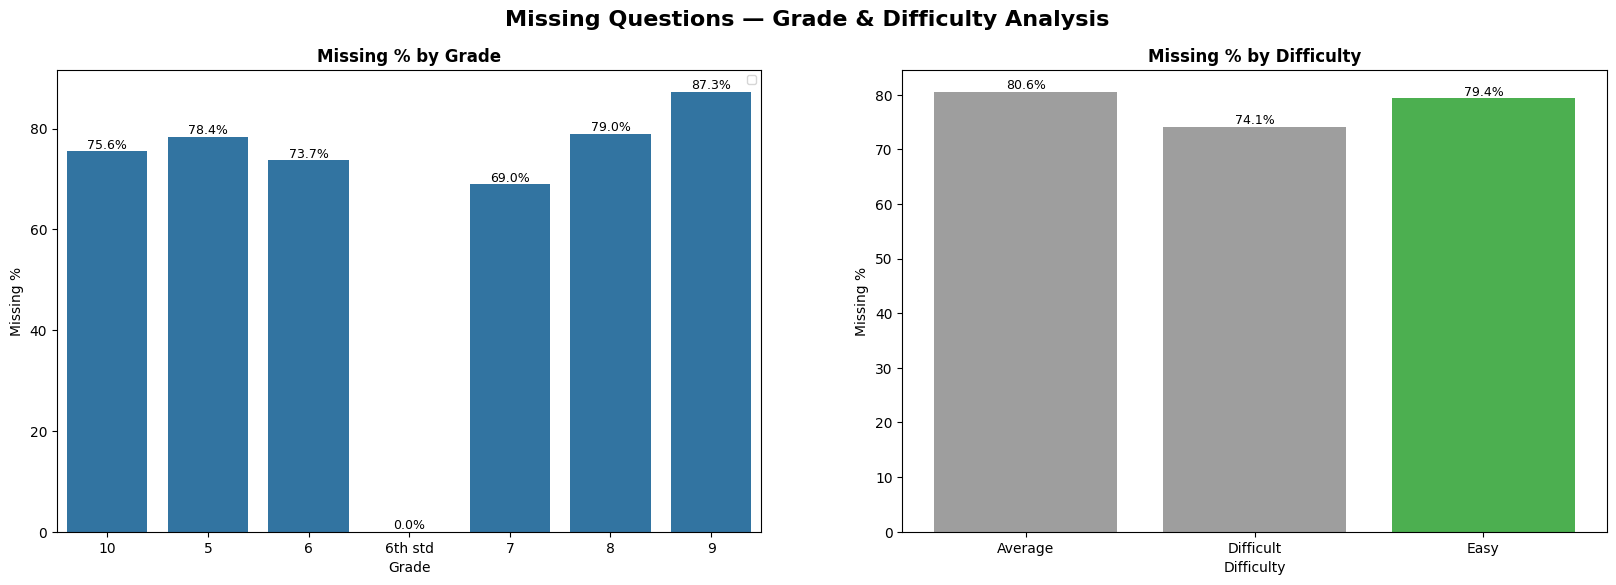

In [ ]:

fig4, axes4 = plt.subplots(1, 2, figsize=(20, 6))
fig4.suptitle("Missing Questions — Grade & Difficulty Analysis", fontsize=16, fontweight="bold")

combined["class"] = combined["class"].astype(str)
missing["class"]  = missing["class"].astype(str)

ax = axes4[0]
total_by_grade    = combined.groupby("class")["text"].count()
missing_by_grade  = missing["class"].value_counts()
grade_df["missing_pct"] = (grade_df["missing"] / grade_df["total"] * 100).replace([np.inf, -np.inf], np.nan).fillna(0)
grade_df = grade_df.sort_index().reset_index()
sns.barplot(data=grade_df, x="class", y="missing_pct", ax=ax)
ax.set_title("Missing % by Grade", fontweight="bold")
ax.set_xlabel("Grade")
ax.set_ylabel("Missing %")
ax.legend(fontsize=8)
for i, row in grade_df.iterrows():
    ax.text(i, row["missing_pct"] + 0.5, f'{row["missing_pct"]:.1f}%', ha="center", fontsize=9)

ax = axes4[1]
total_by_diff    = combined.groupby("difficulty")["text"].count()
missing_by_diff  = missing["difficulty"].value_counts()
diff_df["missing_pct"] = (diff_df["missing"] / diff_df["total"] * 100).replace([np.inf, -np.inf], np.nan).fillna(0)
diff_df["missing_pct"] = diff_df["missing"] / diff_df["total"] * 100
diff_df = diff_df.reset_index()
colors = {"easy": "#4CAF50", "medium": "#4CAF50", "hard": "#4CAF50"}
bar_colors = [colors.get(d.lower(), "#9E9E9E") for d in diff_df["difficulty"]]
ax.bar(diff_df["difficulty"], diff_df["missing_pct"], color=bar_colors)
ax.set_title("Missing % by Difficulty", fontweight="bold")
ax.set_xlabel("Difficulty")
ax.set_ylabel("Missing %")
for i, row in diff_df.iterrows():
    ax.text(i, row["missing_pct"] + 0.5, f'{row["missing_pct"]:.1f}%', ha="center", fontsize=9)